**Лабораторная работа №1**

Самостоятельно написать код, реализующий искусственный нейрон с сигма-функцией активации, и возможность строить на его основе многослойные сети. Код должен также реализовывать градиентный спуск и обратное распространение ошибки.
На основе вашего кода:

1.	Решить задачу  классификации датаcета Iris одним нейроном.
2.	Решить задачу  классификации датаcета Iris одним  нейросетью из 2 слоев по 10 нейронов в слое.
3.	Отрисовать разделяющую линию для обеих моделей. Сравнить метрики классификации.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

In [2]:
# Функция активации
class Sigmoid:
    @staticmethod
    def forward(x):
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def backward(x, grad_output):
        sig = Sigmoid.forward(x)
        return grad_output * sig * (1 - sig)

In [3]:
# Слой полносвязной сети
class Dense:
    def __init__(self, input_size, output_size, activation=Sigmoid):
        # Инициализация весов случайными малыми числами
        self.W = np.random.randn(input_size, output_size) * 0.1
        self.b = np.zeros((1, output_size))
        self.activation = activation

        # Для хранения промежуточных результатов при прямом проходе
        self.X = None
        self.Z = None

    def forward(self, X):
        self.X = X  # сохраняем вход для обратного прохода
        self.Z = X @ self.W + self.b  # линейная комбинация
        if self.activation is not None:
            return self.activation.forward(self.Z)
        return self.Z

    def backward(self, grad_output, lr):
        # grad_output – градиент по выходу слоя
        if self.activation is not None:
            grad_Z = self.activation.backward(self.Z, grad_output)
        else:
            grad_Z = grad_output

        # Градиенты по весам и смещениям
        dW = self.X.T @ grad_Z / self.X.shape[0]
        db = np.sum(grad_Z, axis=0, keepdims=True) / self.X.shape[0]
        # Градиент по входу слоя (для передачи предыдущему слою)
        dX = grad_Z @ self.W.T

        # Обновление параметров (стохастический градиентный спуск на мини-батче)
        self.W -= lr * dW
        self.b -= lr * db

        return dX

In [4]:
# Функция потерь
class BinaryCrossEntropy:
    @staticmethod
    def forward(y_pred, y_true):
        # y_true: (N,1) или (N,)
        y_true = y_true.reshape(-1, 1)
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)  # избегаем log(0)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    @staticmethod
    def backward(y_pred, y_true):
        y_true = y_true.reshape(-1, 1)
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
        return (y_pred - y_true) / (y_pred * (1 - y_pred)) / y_true.shape[0]

In [5]:
# Нейронная сеть
class NeuralNetwork:
    def __init__(self, layers):
        self.layers = layers # список объектов Dense (без учёта входного слоя)

    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, grad_output, lr):
        grad = grad_output
        for layer in reversed(self.layers):
            grad = layer.backward(grad, lr)
        return grad

    def train(self, X, y, epochs, lr, batch_size=32, verbose=True):
        n_samples = X.shape[0]
        loss_history = []
        for epoch in range(epochs):
            # Перемешивание данных
            idx = np.random.permutation(n_samples)
            X_shuffled = X[idx]
            y_shuffled = y[idx]

            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                # Прямой проход
                y_pred = self.forward(X_batch)
                # Обратное распространение
                grad = BinaryCrossEntropy.backward(y_pred, y_batch)
                self.backward(grad, lr)

            # Полная потеря на всех данных
            y_pred_all = self.forward(X)
            loss = BinaryCrossEntropy.forward(y_pred_all, y)
            loss_history.append(loss)
            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        return loss_history

    def predict(self, X):
        prob = self.forward(X)
        return (prob >= 0.5).astype(int)

In [22]:
# Подготовка данных
iris = load_iris()
X = iris.data[:, 2:4]  # длина, ширина лепестка
y = iris.target
# setosa - 0, versicolor - 1
mask = y != 2  # исключаем virginica
X = X[mask]
y = y[mask].reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Нормализация (очень рекомендуется для градиентного спуска)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Форма тренировочных данных:", X_train.shape)
print("Форма тестовых данных:", X_test.shape)

Форма тренировочных данных: (70, 2)
Форма тестовых данных: (30, 2)


In [23]:
# Решить задачу классификации датаcета Iris одним нейроном
single_neuron = NeuralNetwork([Dense(input_size=2, output_size=1, activation=Sigmoid)])

loss_hist = single_neuron.train(X_train, y_train, epochs=1000, lr=0.1, batch_size=16)

y_pred_train = single_neuron.predict(X_train)
y_pred_test = single_neuron.predict(X_test)

print("Один нейрон (логистическая регрессия):")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall   :", recall_score(y_test, y_pred_test))

Epoch 0, Loss: 0.6056
Epoch 100, Loss: 0.1504
Epoch 200, Loss: 0.0874
Epoch 300, Loss: 0.0628
Epoch 400, Loss: 0.0498
Epoch 500, Loss: 0.0415
Epoch 600, Loss: 0.0356
Epoch 700, Loss: 0.0313
Epoch 800, Loss: 0.0280
Epoch 900, Loss: 0.0254
Один нейрон (логистическая регрессия):
Train Accuracy: 1.0
Test Accuracy : 1.0
Precision: 1.0
Recall   : 1.0


In [24]:
# Решить задачу классификации датаcета Iris одним нейросетью из 2 слоев по 10 нейронов в слое
two_layer_nn = NeuralNetwork([
    Dense(input_size=2, output_size=10, activation=Sigmoid),
    Dense(input_size=10, output_size=10, activation=Sigmoid),
    Dense(input_size=10, output_size=1, activation=Sigmoid)
])

loss_hist2 = two_layer_nn.train(X_train, y_train, epochs=2000, lr=0.1, batch_size=16)

y_pred_train2 = two_layer_nn.predict(X_train)
y_pred_test2 = two_layer_nn.predict(X_test)

print("Двухслойная сеть (10,10):")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train2))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test2))
print("Precision:", precision_score(y_test, y_pred_test2))
print("Recall   :", recall_score(y_test, y_pred_test2))

Epoch 0, Loss: 0.6926
Epoch 100, Loss: 0.6915
Epoch 200, Loss: 0.6913
Epoch 300, Loss: 0.6912
Epoch 400, Loss: 0.6911
Epoch 500, Loss: 0.6913
Epoch 600, Loss: 0.6908
Epoch 700, Loss: 0.6908
Epoch 800, Loss: 0.6903
Epoch 900, Loss: 0.6899
Epoch 1000, Loss: 0.6894
Epoch 1100, Loss: 0.6889
Epoch 1200, Loss: 0.6881
Epoch 1300, Loss: 0.6871
Epoch 1400, Loss: 0.6857
Epoch 1500, Loss: 0.6843
Epoch 1600, Loss: 0.6811
Epoch 1700, Loss: 0.6764
Epoch 1800, Loss: 0.6696
Epoch 1900, Loss: 0.6588
Двухслойная сеть (10,10):
Train Accuracy: 0.9571428571428572
Test Accuracy : 0.9333333333333333
Precision: 0.8666666666666667
Recall   : 1.0


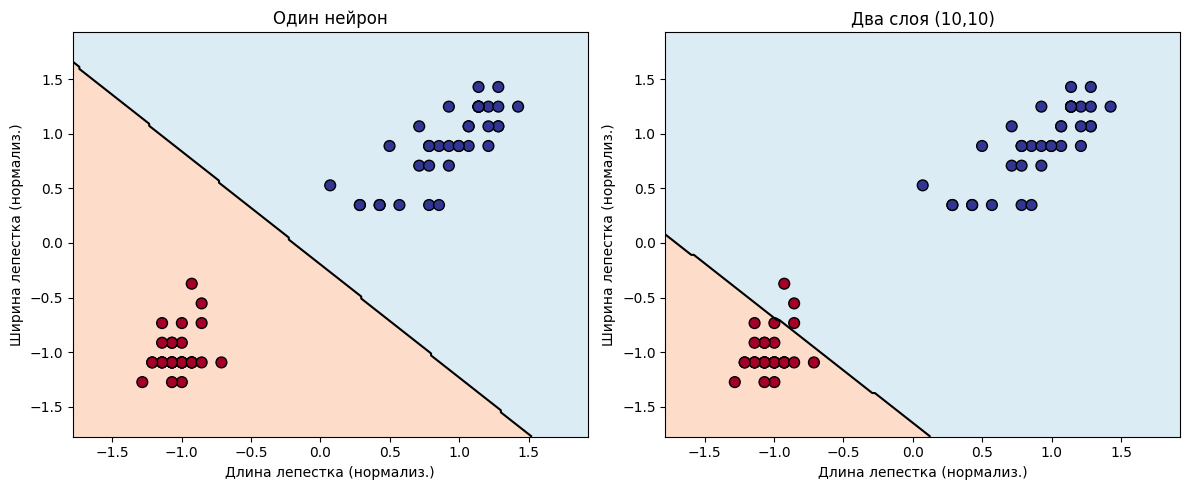

Отчёт для одного нейрона (тест):
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        17
  Versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Отчёт для двухслойной сети (тест):
              precision    recall  f1-score   support

      Setosa       1.00      0.88      0.94        17
  Versicolor       0.87      1.00      0.93        13

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30



In [25]:
# Визуализация
def plot_decision_boundary(model, X, y, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # Создаём сетку
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)

    # Отрисовка областей
    ax.contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.RdYlBu, levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, preds, levels=[0.5], colors='k', linewidths=1.5)

    # Точки данных
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolors='k', cmap=plt.cm.RdYlBu, s=60)
    ax.set_xlabel('Длина лепестка (нормализ.)')
    ax.set_ylabel('Ширина лепестка (нормализ.)')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(single_neuron, X_train, y_train, 'Один нейрон', ax=axes[0])
plot_decision_boundary(two_layer_nn, X_train, y_train, 'Два слоя (10,10)', ax=axes[1])
plt.tight_layout()
plt.show()

print("Отчёт для одного нейрона (тест):")
print(classification_report(y_test, y_pred_test, target_names=['Setosa', 'Versicolor']))

print("Отчёт для двухслойной сети (тест):")
print(classification_report(y_test, y_pred_test2, target_names=['Setosa', 'Versicolor']))